In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, classification_report, confusion_matrix, root_mean_squared_error, mean_absolute_error, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

=== BÖLÜM 1: SINIFLANDIRMA (NE EKELİM?) ===
1. Orijinal veri okunuyor ve ikiye bölünüyor...
-> 'toprak_verileri.csv' ve 'iklim_verileri.csv' oluşturuldu.
2. Veriler ortak ID üzerinden birleştiriliyor...
3. Sınıflandırma Modeli Eğitiliyor...
Cross-Validation Accuracy Scores: 0.9886, 1.0000, 0.9943, 0.9972, 0.9943
Sınıflandırma Modeli Test Sonuçları:
['muskmelon' 'watermelon' 'papaya' 'papaya' 'apple']
Accuracy: 0.9909
F1 Score: 0.9910


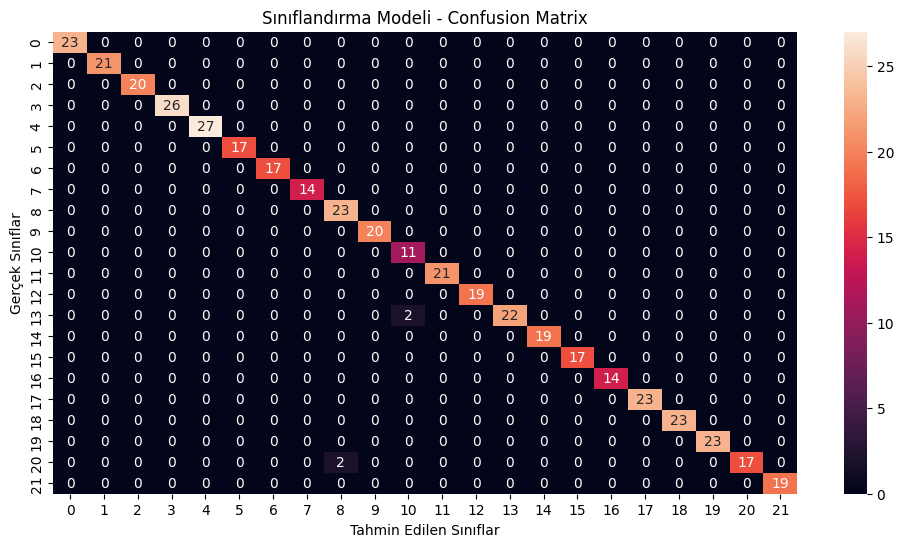

-> Sınıflandırma Modeli Hazır!



In [ ]:
print("=== BÖLÜM 1: SINIFLANDIRMA (NE EKELİM?) ===")
print("1. Orijinal veri okunuyor ve ikiye bölünüyor...")
ham_veri = pd.read_csv("orijinal_veri.csv")
ham_veri['Tarla_ID'] = range(1, len(ham_veri) + 1) # Numarik ID ekleniyor 

toprak_kismi = ham_veri[['Tarla_ID', 'N', 'P', 'K', 'ph']]
iklim_kismi = ham_veri[['Tarla_ID', 'temperature', 'humidity', 'rainfall', 'label']]
toprak_kismi.to_csv("toprak_verileri.csv", index=False)
iklim_kismi.to_csv("iklim_verileri.csv", index=False)
print("-> 'toprak_verileri.csv' ve 'iklim_verileri.csv' oluşturuldu.")

print("2. Veriler ortak ID üzerinden birleştiriliyor...")
df_toprak = pd.read_csv("toprak_verileri.csv")
df_iklim = pd.read_csv("iklim_verileri.csv")
birlesik_veri_1 = pd.merge(df_toprak, df_iklim, on="Tarla_ID")

print("3. Sınıflandırma Modeli Eğitiliyor...")
X1 = birlesik_veri_1.drop(['Tarla_ID', 'label'], axis=1)
y1 = birlesik_veri_1['label']
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)
model1 = RandomForestClassifier(n_estimators=100, random_state=42)
model1.fit(X_train1, y_train1)
y_pred=model1.predict(X_test1)

X_train_1_1, X_val_1_1, y_train_1_1, y_val_1_1 = train_test_split(X_train1, y_train1, test_size=0.25, random_state=42)

#Cross-Validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model1, X_train1, y_train1, cv=5)
formatted_scores = ", ".join([f"{score:.4f}" for score in cv_scores])
print(f"Cross-Validation Accuracy Scores: {formatted_scores}")

# Modelin başarısını test ediyoruz
# Classification Report, Accuracy Score
print("Sınıflandırma Modeli Test Sonuçları:")
print(y_pred[0:5]) # İlk 5 tahmini göster
accuracy = model1.score(X_test1, y_test1)
f1score = f1_score(y_test1, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1score:.4f}")

cmax = confusion_matrix(y_test1, y_pred)
plt.figure(figsize=(12, 6))
sns.heatmap(cmax, annot=True, fmt='d', cmap='rocket')
plt.xlabel("Tahmin Edilen Sınıflar")
plt.ylabel("Gerçek Sınıflar")
plt.title("Sınıflandırma Modeli - Confusion Matrix")
plt.show()

print("-> Sınıflandırma Modeli Hazır!\n")

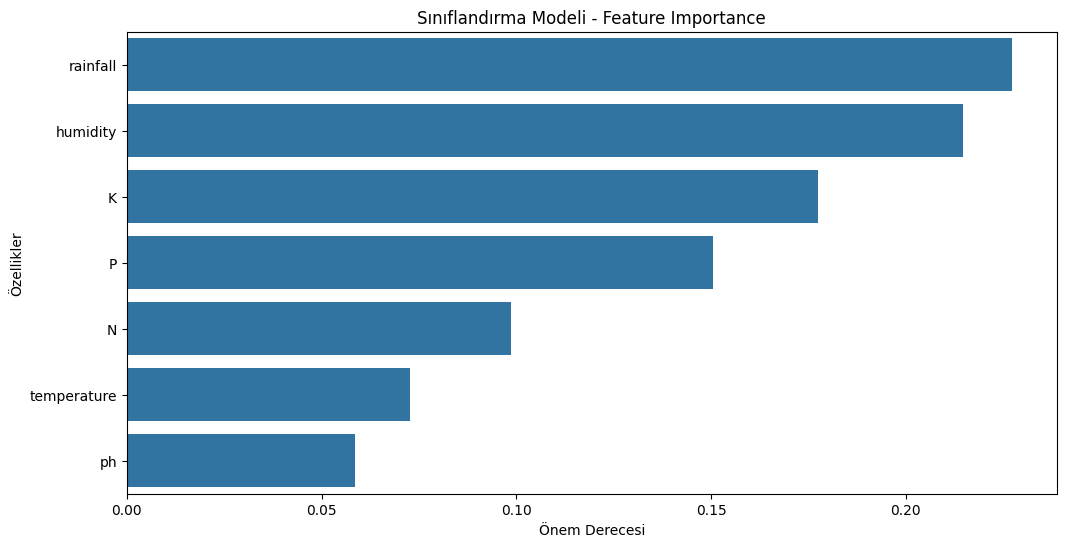

In [5]:
# Feature Importance
feature_importances = model1.feature_importances_
feature_names = X1.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Sınıflandırma Modeli - Feature Importance")
plt.xlabel("Önem Derecesi")
plt.ylabel("Özellikler")
plt.show()

In [3]:
print("=== BÖLÜM 2: REGRESYON (NE KADAR ÜRÜN ALIRIZ?) ===")
print("1. Dış veri setleri yükleniyor ve temizleniyor...")
df_yield = pd.read_csv('yield.csv')
df_temp = pd.read_csv('temp.csv')
df_rain = pd.read_csv('rainfall.csv')
df_pest = pd.read_csv('pesticides.csv')

df_yield.columns = df_yield.columns.str.strip()
df_temp.columns = df_temp.columns.str.strip()
df_rain.columns = df_rain.columns.str.strip()
df_pest.columns = df_pest.columns.str.strip()

df_temp.rename(columns={'country': 'Area', 'year': 'Year'}, inplace=True)

if 'Item' in df_pest.columns:
    df_pest = df_pest.drop('Item', axis=1)
    
if 'Value' in df_pest.columns:
    df_pest.rename(columns={'Value': 'Pesticides'}, inplace=True)
elif 'pesticides_tonnes' in df_pest.columns:
    df_pest.rename(columns={'pesticides_tonnes': 'Pesticides'}, inplace=True)

if 'Value' in df_yield.columns:
    df_yield.rename(columns={'Value': 'Yield'}, inplace=True)
elif 'hg/ha_yield' in df_yield.columns:
    df_yield.rename(columns={'hg/ha_yield': 'Yield'}, inplace=True)

print("2. Veriler birleştiriliyor...")
df_merged = pd.merge(df_yield, df_temp, on=['Area', 'Year'], how='inner')
df_merged = pd.merge(df_merged, df_rain, on=['Area', 'Year'], how='inner')
df_merged = pd.merge(df_merged, df_pest, on=['Area', 'Year'], how='inner')

df_merged.rename(columns={
    'average_rain_fall_mm_per_year': 'Rainfall', 
    'avg_temp': 'Temperature'
}, inplace=True)

# --- HATALI VERİ (..) TEMİZLEME İŞLEMİ EKLENDİ ---
sayisal_sutunlar = ['Year', 'Rainfall', 'Pesticides', 'Temperature', 'Yield']
for sutun in sayisal_sutunlar:
    # Sayı olmayan her şeyi (mesela '..') NaN (boşluk) yapar
    df_merged[sutun] = pd.to_numeric(df_merged[sutun], errors='coerce')

# İçinde NaN (boş) olan satırları komple siliyoruz ki model çökmesin
df_merged.dropna(inplace=True)
# --------------------------------------------------

print("3. Regresyon Modeli Eğitiliyor...")
X2 = df_merged[['Area', 'Item', 'Year', 'Rainfall', 'Pesticides', 'Temperature']]
y2 = df_merged['Yield']

donusturucu = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), ['Area', 'Item'])], remainder='passthrough')

model2 = Pipeline(steps=[
    ('preprocessor', donusturucu),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)
model2.fit(X_train2, y_train2)
r_2 = r2_score(y_test2, model2.predict(X_test2))
rmse = root_mean_squared_error(y_test2, model2.predict(X_test2))
mae = mean_absolute_error(y_test2, model2.predict(X_test2))
print(f"-> Random Forest Regresyon Modeli Hazır!")
print(f"Random Forest Regresyon Modeli Test Sonuçları:\nR² Skoru: {r_2:.4f}\nRMSE: {rmse:.4f} \nMAE: {mae:.4f}")
print("Sistem başarıyla test edildi.")

=== BÖLÜM 2: REGRESYON (NE KADAR ÜRÜN ALIRIZ?) ===
1. Dış veri setleri yükleniyor ve temizleniyor...
2. Veriler birleştiriliyor...
3. Regresyon Modeli Eğitiliyor...
-> Random Forest Regresyon Modeli Hazır!
Random Forest Regresyon Modeli Test Sonuçları:
R² Skoru: 0.9870
RMSE: 9640.2321 
MAE: 3360.7395
Sistem başarıyla test edildi.


In [4]:
# Test with another simple model for comparison
from sklearn.linear_model import LinearRegression
model3 = Pipeline(steps=[
    ('preprocessor', donusturucu),
    ('regressor', LinearRegression())
])
model3.fit(X_train2, y_train2)
r_2_lr = r2_score(y_test2, model3.predict(X_test2))
rmse_lr = root_mean_squared_error(y_test2, model3.predict(X_test2))
mae_lr = mean_absolute_error(y_test2, model3.predict(X_test2))

print(f"Linear Regression Modeli Test Sonuçları:\nR² Skoru: {r_2_lr:.4f}\nRMSE: {rmse_lr:.4f} \nMAE: {mae_lr:.4f}")
# Linear Regression modelinin sonuçları açık bir şekilde Random Forest modelinden daha kötü çıkıyor,
# bu da verinin doğrusal olmayan ilişkiler içerdiğini ve Random Forest'ın bu ilişkileri daha iyi yakalayabildiğini gösteriyor.

Linear Regression Modeli Test Sonuçları:
R² Skoru: 0.6799
RMSE: 47872.9067 
MAE: 31497.5054


In [13]:
# Linear Regression After min-max scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Apply MinMaxScaler to the numeric columns after OneHotEncoder transformation
donusturucu_scaled = ColumnTransformer(
	transformers=[
		('cat', OneHotEncoder(handle_unknown='ignore'), ['Area', 'Item']),
		('num', MinMaxScaler(), ['Year', 'Rainfall', 'Pesticides', 'Temperature'])
	],
	remainder='passthrough'
)

# Update the pipeline to include the new ColumnTransformer
model_lr_scaled = Pipeline(steps=[
	('preprocessor', donusturucu_scaled),
	('regressor', LinearRegression())
])

# Fit the model and evaluate
model_lr_scaled.fit(X_train2, y_train2)
r_2_lr_scaled = r2_score(y_test2, model_lr_scaled.predict(X_test2))
rmse_lr_scaled = root_mean_squared_error(y_test2, model_lr_scaled.predict(X_test2))
mae_lr_scaled = mean_absolute_error(y_test2, model_lr_scaled.predict(X_test2))

print(f"Linear Regression (Min-Max Scaled) Modeli Test Sonuçları:\nR² Skoru: {r_2_lr_scaled:.4f}\nRMSE: {rmse_lr_scaled:.4f} \nMAE: {mae_lr_scaled:.4f}")


Linear Regression (Min-Max Scaled) Modeli Test Sonuçları:
R² Skoru: 0.7503
RMSE: 42283.9245 
MAE: 29631.2715
